# XGBoost — Strategy Discovery

**Prerequisites:**
- Run `data/01_build_features.ipynb` to generate `data/latest_features.jsonl`
- Run `xgb/02_export.ipynb` to export the model to `models/`

**Goal:** Find the best scaling-in strategy for XGBoost.

**Method:** Strategy is discovered on the **validation split** (last 20% of candles from training data),
not on unseen forward-test data. This prevents overfitting the strategy to the test set.

**Output:** `data/optimal_strategy_xgb.json`


In [19]:
import sys

sys.path.insert(0, str(__import__("pathlib").Path.cwd().parent))

import json
import random
import sqlite3
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from strategy_engine import StrategyGrid, WalkForwardEvaluator, run_scaling
from technicals import CandleRecord, IndicatorSnapshot, compute_all
from tqdm import tqdm

random.seed(42)
np.random.seed(42)

FEATURES_PATH = Path("../../data/latest_features.jsonl")
DB_PATH = Path("../../data/collection.db")
MAX_BID = 0.85
WARM_UP = 21

## 1. Load feature config and hyperparameters

Features and hyperparameters from the JSON config. Model will be trained
on the **training split only** (first 80%) to avoid data leakage during
strategy evaluation.


In [20]:
# Load feature config (not the exported model — we train on 80% below)
import json as _json

import xgboost as xgb_lib
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler

with open(Path("../../data/optimal_features_xgb.json")) as _f:
    _config = _json.load(_f)
    feat_cols = _config["features"]
    _hyperparams = _config.get("hyperparameters", {})
    INT_PARAMS = {"max_depth", "min_child_weight", "n_estimators"}
    _hyperparams = {k: int(v) if k in INT_PARAMS else float(v) for k, v in _hyperparams.items()}

print(f"XGB config: {len(feat_cols)} features, params={_hyperparams}")

XGB config: 11 features, params={'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 10, 'subsample': 0.8, 'colsample_bytree': 0.8}


## 2. Load data, split, and train on training set

Model is trained on the **first 80%** of candles (training set).
Strategy is discovered on the **last 20%** (validation set).
This prevents data leakage — the model never sees validation data during training.


In [21]:
rows = []
with open(FEATURES_PATH) as f:
    for line in f:
        rows.append(json.loads(line))

df = pd.DataFrame(rows)
df["target"] = (df["outcome"] == "UP").astype(int)

NON_FEAT = {
    "candle_id",
    "session",
    "timestamp",
    "elapsed_pct",
    "btc_price",
    "up_best_bid",
    "up_best_ask",
    "up_bid_depth",
    "up_ask_depth",
    "down_best_bid",
    "down_best_ask",
    "down_bid_depth",
    "down_ask_depth",
    "market_volume",
    "outcome",
    "target",
}
all_feat_cols = sorted([c for c in df.columns if c not in NON_FEAT])
df[all_feat_cols] = df[all_feat_cols].fillna(0.0)

candle_ids = df["candle_id"].unique()
split_idx = int(len(candle_ids) * 0.8)
val_ids = set(candle_ids[split_idx:])
df_val = df[df["candle_id"].isin(val_ids)]

print(f"Total candles: {len(candle_ids)}")
print(f"Validation candles: {df_val['candle_id'].nunique()} (last 20%)")
print(f"Validation rows: {len(df_val):,}")

# Train model on TRAINING SET ONLY (first 80%)
df_train = df[df["candle_id"].isin(set(candle_ids[:split_idx]))]
df_train[feat_cols] = df_train[feat_cols].fillna(0.0)

scaler = StandardScaler()
X_train = scaler.fit_transform(df_train[feat_cols].values)
y_train = df_train["target"].values

base_model = xgb_lib.XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1,
    **_hyperparams,
)
base_model.fit(X_train, y_train)
model = CalibratedClassifierCV(base_model, method="isotonic", cv=3)
model.fit(X_train, y_train)
print(f"Trained XGB (calibrated) on {len(df_train):,} rows ({df_train['candle_id'].nunique()} candles)")

Total candles: 4565
Validation candles: 913 (last 20%)
Validation rows: 43,122
Trained XGB (calibrated) on 173,573 rows (3652 candles)


## 3. Build per-snapshot predictions on validation set

In [22]:
all_cd = []

for cid in df_val["candle_id"].unique():
    snap_rows = df_val[df_val["candle_id"] == cid].sort_values("timestamp")
    if len(snap_rows) < 5:
        continue
    truth = int(snap_rows["target"].iloc[0])
    X = scaler.transform(snap_rows[feat_cols].values)
    probs = model.predict_proba(X)[:, 1]

    up_asks = snap_rows["up_best_ask"].values if "up_best_ask" in snap_rows.columns else [None] * len(snap_rows)
    down_asks = snap_rows["down_best_ask"].values if "down_best_ask" in snap_rows.columns else [None] * len(snap_rows)
    elapsed = snap_rows["elapsed_pct"].values

    sd = [
        {
            "tick": i,
            "elapsed_pct": float(elapsed[i]),
            "pred": int(probs[i] >= 0.5),
            "prob": float(probs[i]),
            "up_ask": float(up_asks[i]) if up_asks[i] is not None and np.isfinite(up_asks[i]) else None,
            "down_ask": float(down_asks[i]) if down_asks[i] is not None and np.isfinite(down_asks[i]) else None,
        }
        for i in range(len(snap_rows))
    ]
    all_cd.append({"candle_id": cid, "truth": truth, "snapshots": sd})

print("Built predictions for {len(all_cd)} validation candles")

Built predictions for {len(all_cd)} validation candles


## 4. Grid search + walk-forward evaluation

In [23]:
grid = StrategyGrid()
strategies = grid.generate()
print(f"Generated {len(strategies)} strategy combinations")

evaluator = WalkForwardEvaluator(strategies, all_cd, n_folds=5, max_bid=MAX_BID)
results_df = evaluator.run()
print(f"Walk-forward complete: {len(results_df)} strategies evaluated across 5 folds")

Generated 3815 strategy combinations
Walk-forward complete: 3815 strategies evaluated across 5 folds


## 5. Comparison table (top 15 by mean Sharpe)

In [24]:
top15 = results_df.head(15)

print(f"{'Strategy':<32} {'Sharpe (μ±σ)':>16} {'Return (μ)':>11} {'WR (μ)':>8} {'MaxDD (μ)':>10} {'Bets (μ)':>9}")
print("-" * 92)
for _, row in top15.iterrows():
    print(
        f"{row['strategy']:<32} "
        f"{row['sharpe_mean']:>6.3f} ± {row['sharpe_std']:<5.3f} "
        f"{row['return_mean']:>+9.1f}% "
        f"{row['win_rate_mean'] * 100:>6.1f}% "
        f"{row['max_dd_mean'] * 100:>8.1f}% "
        f"{row['total_bets_mean']:>8.0f}"
    )

Strategy                             Sharpe (μ±σ)  Return (μ)   WR (μ)  MaxDD (μ)  Bets (μ)
--------------------------------------------------------------------------------------------
1x e35%c5 conf>0.55               0.104 ± 0.105     +10.7%   75.1%      5.6%      161
2x e35%c2+e75%c2 conf>0.60        0.102 ± 0.089     +15.6%   76.1%      9.2%      238
2x e35%c1+e75%c1 conf>0.60        0.101 ± 0.090     +16.2%   75.0%      8.6%      241
2x e35%c2+e65%c2 conf>0.60        0.100 ± 0.092     +16.8%   75.9%      9.8%      260
2x e35%c1+e70%c1 conf>0.60        0.100 ± 0.093     +16.7%   75.0%      8.4%      252
1x e35%c2 conf>0.60               0.100 ± 0.081     +10.6%   75.1%      6.2%      161
2x e35%c5+e75%c5 conf>0.55        0.099 ± 0.113     +14.6%   75.7%      8.4%      233
1x e35%c4 conf>0.55               0.099 ± 0.075     +10.8%   74.4%      5.8%      162
2x e35%c5+e70%c5 conf>0.55        0.099 ± 0.118     +15.1%   75.8%      8.5%      245
2x e35%c2+e70%c2 conf>0.60        0.098 ±

## 6. Equity curves

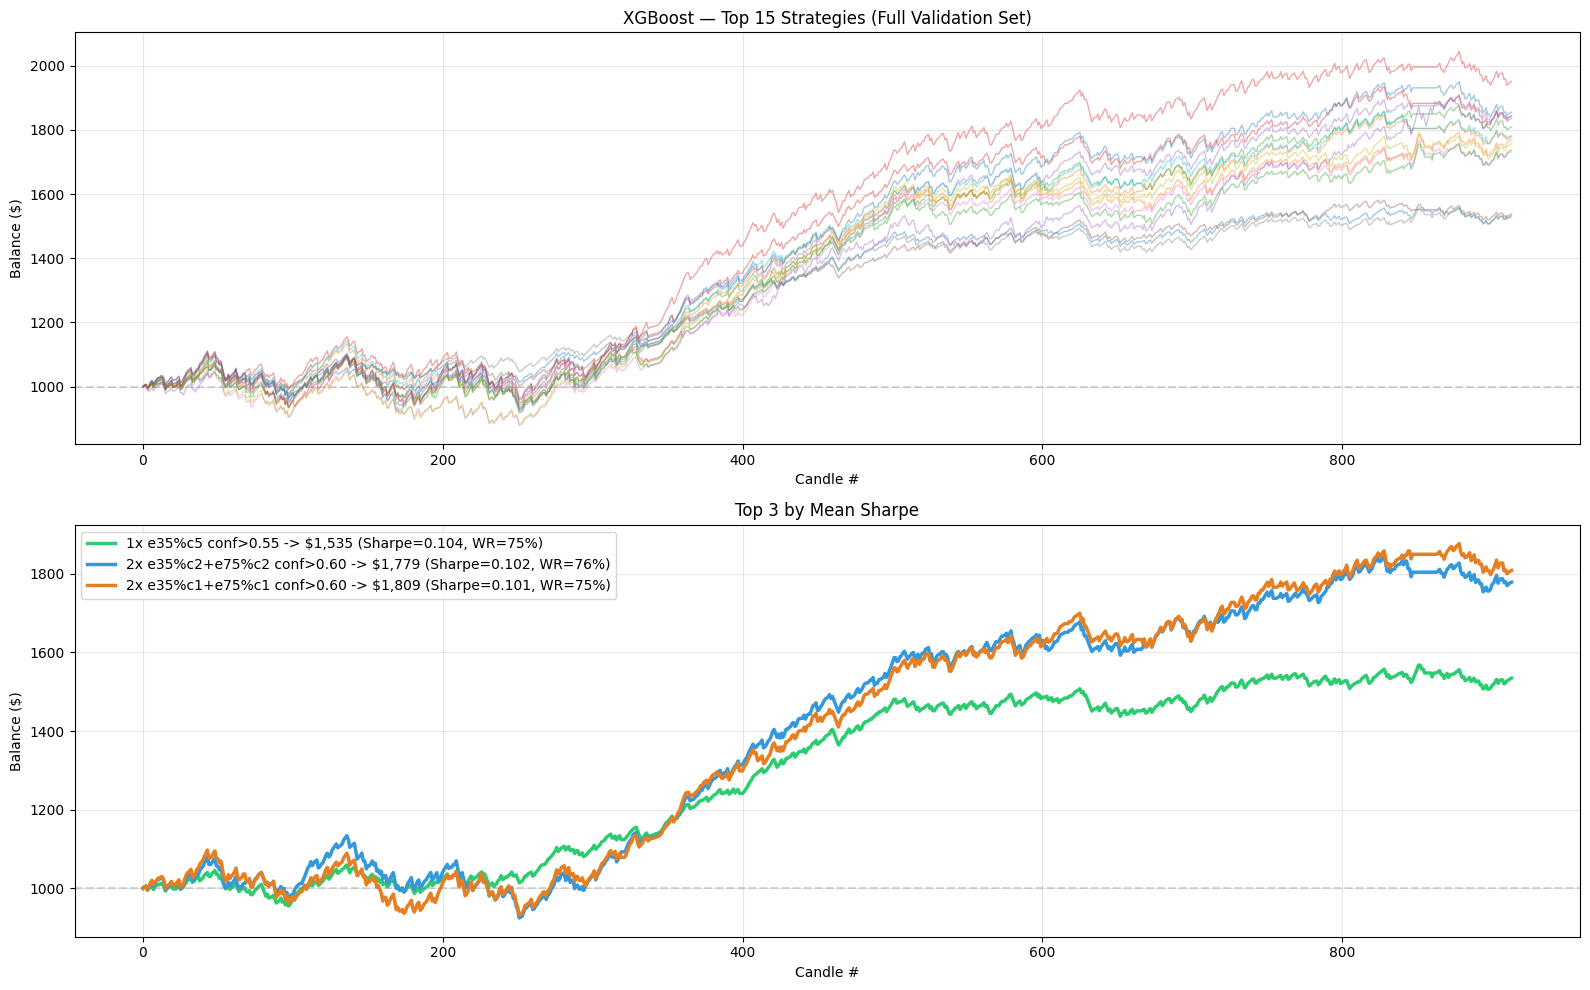

In [25]:
# Run top 3 strategies on full validation set for equity curves
top3_configs = [results_df.iloc[i]["_config"] for i in range(min(3, len(results_df)))]
top3_full = [run_scaling(cfg, all_cd, max_bid=MAX_BID) for cfg in top3_configs]

# Also run all top-15 for the overview plot
top15_configs = [results_df.iloc[i]["_config"] for i in range(min(15, len(results_df)))]
top15_full = [run_scaling(cfg, all_cd, max_bid=MAX_BID) for cfg in top15_configs]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for r in top15_full:
    axes[0].plot(r["history"], alpha=0.4, linewidth=1)
axes[0].axhline(1000, color="gray", linestyle="--", alpha=0.3)
axes[0].set_xlabel("Candle #")
axes[0].set_ylabel("Balance ($)")
axes[0].set_title("XGBoost — Top 15 Strategies (Full Validation Set)")
axes[0].grid(alpha=0.3)

colors = ["#2ecc71", "#3498db", "#e67e22"]
for r, c in zip(top3_full, colors, strict=False):
    sharpe_row = results_df[results_df["strategy"] == r["name"]].iloc[0]
    axes[1].plot(
        r["history"],
        color=c,
        linewidth=2.5,
        label=f"{r['name']} -> ${r['balance']:,.0f} (Sharpe={sharpe_row['sharpe_mean']:.3f}, WR={r['win_rate'] * 100:.0f}%)",
    )
axes[1].axhline(1000, color="gray", linestyle="--", alpha=0.3)
axes[1].set_xlabel("Candle #")
axes[1].set_ylabel("Balance ($)")
axes[1].set_title("Top 3 by Mean Sharpe")
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Save best strategy

In [26]:
best_row = results_df.iloc[0]
best_cfg = best_row["_config"]

config = {
    "model": "xgb",
    "strategy": best_cfg.name,
    "entry_points": best_cfg.entry_points,
    "min_confidence": best_cfg.min_confidence,
    "sharpe_mean": round(best_row["sharpe_mean"], 4),
    "sharpe_std": round(best_row["sharpe_std"], 4),
    "win_rate": round(best_row["win_rate_mean"], 4),
    "return_pct": round(best_row["return_mean"], 2),
    "max_drawdown": round(best_row["max_dd_mean"], 4),
    "n_folds": 5,
    "grid_size": len(results_df),
    "eval_candles": len(all_cd),
    "eval_method": "walk_forward_5_folds",
    "total_bets": int(best_row["total_bets_mean"]),
    "created_at": datetime.now(UTC).isoformat(),
}

out_path = Path("../../data/optimal_strategy_xgb.json")
with open(out_path, "w") as f:
    json.dump(config, f, indent=2)

print(f"Best strategy: {best_cfg.name}")
print(f"  Sharpe: {best_row['sharpe_mean']:.3f} ± {best_row['sharpe_std']:.3f}")
print(f"  Win rate: {best_row['win_rate_mean'] * 100:.1f}%")
print(f"  Return: {best_row['return_mean']:+.1f}%")
print(f"  Max drawdown: {best_row['max_dd_mean'] * 100:.1f}%")
print(f"  Eval method: walk-forward (5 folds, {len(results_df)} strategies)")
print(f"\nSaved to {out_path}")

Best strategy: 1x e35%c5 conf>0.55
  Sharpe: 0.104 ± 0.105
  Win rate: 75.1%
  Return: +10.7%
  Max drawdown: 5.6%
  Eval method: walk-forward (5 folds, 3815 strategies)

Saved to ../../data/optimal_strategy_xgb.json


## 8. (Optional) Forward-test confirmation

Run the chosen strategy on unseen candles from DB to confirm it generalizes.
This is for **reporting only** — the strategy was already selected above on the validation set.

In [27]:
# Load forward-test candles
max_train_ts = df["timestamp"].max()

conn = sqlite3.connect(str(DB_PATH))
candles_df = pd.read_sql(
    f"SELECT * FROM candles WHERE start_time > {max_train_ts} ORDER BY start_time",
    conn,
)
snaps_df = (
    pd.read_sql(
        "SELECT * FROM snapshots WHERE candle_id IN ({}) ORDER BY candle_id, timestamp".format(
            ",".join(f"'{cid}'" for cid in candles_df["candle_id"])
        ),
        conn,
    )
    if len(candles_df) > 0
    else pd.DataFrame()
)
prior_candles_df = pd.read_sql(
    f"SELECT * FROM candles WHERE start_time <= {max_train_ts} ORDER BY start_time DESC LIMIT {WARM_UP}",
    conn,
)
conn.close()

if len(candles_df) == 0:
    print("No forward-test candles available yet. Skip this section.")
else:
    prior_candles_df = prior_candles_df.sort_values("start_time")
    prior_candles = [
        CandleRecord(
            **{
                k: row[k]
                for k in [
                    "candle_id",
                    "start_time",
                    "end_time",
                    "open",
                    "high",
                    "low",
                    "close",
                    "volume",
                    "outcome",
                    "final_ret",
                ]
            }
        )
        for _, row in prior_candles_df.iterrows()
    ]

    fwd_rows = []
    for _, cr in tqdm(candles_df.iterrows(), total=len(candles_df), desc="Forward-test features"):
        cid = cr["candle_id"]
        candle = CandleRecord(
            **{
                k: cr[k]
                for k in [
                    "candle_id",
                    "start_time",
                    "end_time",
                    "open",
                    "high",
                    "low",
                    "close",
                    "volume",
                    "outcome",
                    "final_ret",
                ]
            }
        )
        snap_rows = snaps_df[snaps_df["candle_id"] == cid]
        if len(snap_rows) < 5:
            prior_candles.append(candle)
            continue
        snapshots = []
        for _, s in snap_rows.iterrows():
            ob = json.loads(s["orderbook_json"])
            snapshots.append(
                IndicatorSnapshot(
                    candle_id=cid,
                    timestamp=s["timestamp"],
                    elapsed_pct=s["elapsed_pct"],
                    btc_price=s["btc_price"],
                    btc_bid=s["btc_bid"],
                    btc_ask=s["btc_ask"],
                    up_bids=[ob["up_bids"][0]] if ob.get("up_bids") else [],
                    up_asks=[ob["up_asks"][0]] if ob.get("up_asks") else [],
                    down_bids=[ob["down_bids"][0]] if ob.get("down_bids") else [],
                    down_asks=[ob["down_asks"][0]] if ob.get("down_asks") else [],
                    market_volume=s["market_volume"],
                )
            )
        for si in range(len(snapshots)):
            indicators = compute_all(prior_candles, candle.open, snapshots[: si + 1])
            snap = snapshots[si]
            fwd_rows.append(
                {
                    "candle_id": cid,
                    "timestamp": snap.timestamp,
                    "elapsed_pct": snap.elapsed_pct,
                    "btc_price": snap.btc_price,
                    "up_best_ask": snap.up_asks[0][0] if snap.up_asks else None,
                    "down_best_ask": snap.down_asks[0][0] if snap.down_asks else None,
                    **indicators,
                    "outcome": candle.outcome,
                }
            )
        prior_candles.append(candle)

    df_fwd = pd.DataFrame(fwd_rows)
    df_fwd["target"] = (df_fwd["outcome"] == "UP").astype(int)
    df_fwd[all_feat_cols] = df_fwd[all_feat_cols].fillna(0.0)

    fwd_cd = []
    for cid in df_fwd["candle_id"].unique():
        snap_rows = df_fwd[df_fwd["candle_id"] == cid].sort_values("timestamp")
        if len(snap_rows) < 5:
            continue
        truth = int(snap_rows["target"].iloc[0])
        X = scaler.transform(snap_rows[feat_cols].values)
        probs = model.predict_proba(X)[:, 1]
        up_asks = snap_rows["up_best_ask"].values
        down_asks = snap_rows["down_best_ask"].values
        elapsed = snap_rows["elapsed_pct"].values
        sd = [
            {
                "tick": i,
                "elapsed_pct": float(elapsed[i]),
                "pred": int(probs[i] >= 0.5),
                "prob": float(probs[i]),
                "up_ask": float(up_asks[i]) if up_asks[i] is not None and np.isfinite(up_asks[i]) else None,
                "down_ask": float(down_asks[i]) if down_asks[i] is not None and np.isfinite(down_asks[i]) else None,
            }
            for i in range(len(snap_rows))
        ]
        fwd_cd.append({"candle_id": cid, "truth": truth, "snapshots": sd})

    # Run the chosen strategy on forward-test
    fwd_result = run_scaling(best_cfg, fwd_cd, max_bid=MAX_BID)

    print(f"\nForward-test confirmation ({len(fwd_cd)} unseen candles):")
    print(f"  Strategy: {best_cfg.name}")
    print(f"  Bets: {fwd_result['total_bets']}")
    print(f"  Win rate: {fwd_result['win_rate'] * 100:.1f}%")
    print(f"  Return: {fwd_result['return_pct']:+.1f}%")
    print(f"  Max DD: {fwd_result['max_dd'] * 100:.1f}%")
    print(f"  Sharpe: {fwd_result['sharpe']:.3f}")
    print(f"  Balance: ${fwd_result['balance']:,.2f}")

Forward-test features: 100%|██████████| 207/207 [00:01<00:00, 137.79it/s]



Forward-test confirmation (207 unseen candles):
  Strategy: 1x e35%c5 conf>0.55
  Bets: 183
  Win rate: 69.4%
  Return: -2.2%
  Max DD: 10.9%
  Sharpe: -0.017
  Balance: $977.51


## Conclusion

Best XGBoost strategy discovered via **parametric grid search** over ~3,800 combinations
with **walk-forward validation** (5 folds). Strategy selected by highest **mean Sharpe ratio**
across folds.

Model was trained on the **first 80%** of candles — no data leakage.

Saved to `data/optimal_strategy_xgb.json`.

**Note:** The exported model in `models/` (from `02_export`) is trained on ALL data
for maximum live performance. The strategy was evaluated on held-out data to prevent overfitting.